# Exoplanet Analysis Tools - 07: Gaussian Processes and stellar activity (TOI-1736)

Stellar activity — spots and faculae rotating across the disk — imprints quasi-periodic
signals in both photometry and radial velocities that can mimic or mask planetary signals.
This notebook shows the package's tools for **modelling stellar activity with Gaussian
Processes (GPs)** and for **diagnosing activity in RVs using activity indicators**, using
the real data from [Martioli et al. (2023)](https://ui.adsabs.harvard.edu/abs/2023A%26A...680A..84M/abstract)
on **TOI-1736**, a bright G star hosting a transiting sub-Neptune (TOI-1736 b, P ~ 7.07 d)
and a massive, eccentric, long-period companion (TOI-1736 c, P ~ 570 d).

We cover:
1. A quasi-periodic **GP model of the TESS photometry** (stellar rotation).
2. **Periodograms** of the RVs and of the activity indicators.
3. **Correlations** between the RVs (and their residuals) and the activity indicators
   (FWHM, BIS, S-index, H-alpha).
4. Removing activity trends from the RVs.

The SOPHIE RVs and activity indicators, and the TESS light curves, are the same data used
in the paper; please cite Martioli et al. (2023) when using them.

## 1. A GP model of the TESS photometry

The package models stellar rotation with a **quasi-periodic** GP kernel (an exponential-sine-
squared periodic term multiplied by a squared-exponential decay), via
`gp_lib.star_rotation_gp`. Its parameters are the rotation period `Prot`, the amplitude, the
decay timescale (the coherence time of the spot pattern), and a smoothing factor.

We load the TESS light curves, normalize and bin them (to make the GP tractable — a GP scales
as O(N^3), so we bin to 2-hour cadence for this demo), and fit the rotation GP to the early
three sectors, which are contiguous.

In [1]:
%matplotlib inline
import glob, os
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits
from exoplanet_analysis import gp_lib, fitlib, rvutils, timeseries_lib

from exoplanet_analysis import datasets
# Download the tutorial data on first run (from the shared Google Drive
# folder). If already present under notebooks/data/, nothing is downloaded.
datasets.ensure("TOI-1736")
DATA = "data/TOI-1736/"
os.makedirs("outputs", exist_ok=True)

def load_tess(fitsfile, bin_hours=2.0):
    d = fits.getdata(fitsfile, 1)
    t = d["TIME"] + 2457000.0
    fl = d["PDCSAP_FLUX"]; fe = d["PDCSAP_FLUX_ERR"]; q = d["QUALITY"]
    g = np.isfinite(t) & np.isfinite(fl) & np.isfinite(fe) & (q == 0)
    t, fl, fe = t[g], fl[g], fe[g]
    med = np.median(fl)
    bt, bf, be = fitlib.bin_data(t, fl/med, fe/med, median=False, binsize=bin_hours/24.0)
    ok = np.isfinite(bf) & np.isfinite(be)
    return bt[ok], bf[ok], be[ok]

files = sorted(glob.glob(DATA + "tess*.fits"))
sectors = []
for f in files:
    bt, bf, be = load_tess(f)
    s = f.split("-s")[1][:4]
    sectors.append((s, bt, bf, be))
    print("sector {}: {} binned points, BJD {:.1f}-{:.1f}".format(s, len(bt), bt.min(), bt.max()))

Dataset 'TOI-1736' already present at /home/claude/ExoplanetAnalysisTools/notebooks/data/TOI-1736


sector 0018: 253 binned points, BJD 2458790.7-2458814.2


sector 0019: 286 binned points, BJD 2458816.1-2458841.0
sector 0025: 294 binned points, BJD 2458983.7-2459009.3


sector 0052: 282 binned points, BJD 2459718.7-2459743.1


sector 0058: 328 binned points, BJD 2459882.4-2459910.0


sector 0059: 278 binned points, BJD 2459911.6-2459936.7


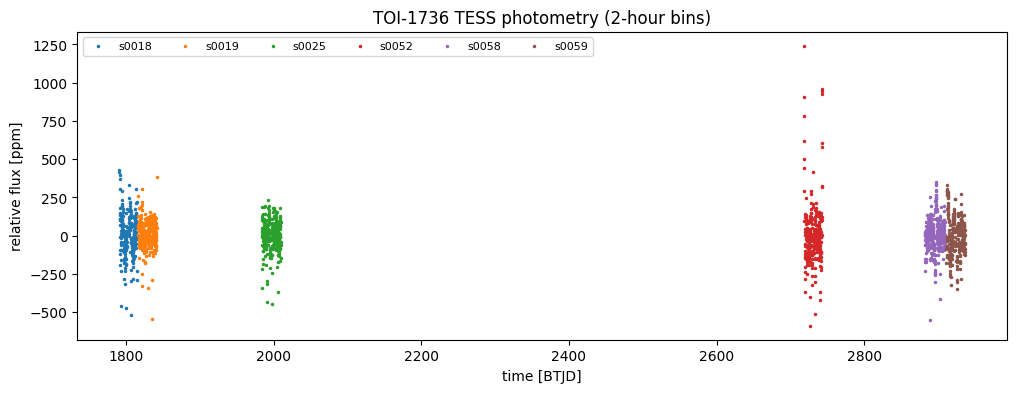

In [2]:
# overview of all sectors (note the multi-year baseline with large gaps)
fig, ax = plt.subplots(figsize=(12, 4))
for s, bt, bf, be in sectors:
    ax.plot(bt - 2457000, (bf - 1)*1e6, ".", ms=3, label="s"+s)
ax.set_xlabel("time [BTJD]"); ax.set_ylabel("relative flux [ppm]")
ax.set_title("TOI-1736 TESS photometry (2-hour bins)"); ax.legend(ncol=6, fontsize=8)
plt.show()

In [3]:
# Fit the quasi-periodic rotation GP to the three contiguous early sectors (18, 19, 25).
t = np.concatenate([s[1] for s in sectors[:3]])
y = np.concatenate([s[2] for s in sectors[:3]]) - 1.0   # variations around zero
yerr = np.concatenate([s[3] for s in sectors[:3]])

# a GLS periodogram gives a good starting guess for the rotation period
gls = timeseries_lib.periodogram(t, y, yerr, nyquist_factor=0.5, probabilities=[0.001],
                                 npeaks=1, y_label="flux", plot=False)
print("GLS starting period: {:.2f} d".format(gls["period"]))

gp = gp_lib.star_rotation_gp(
    t, y, yerr, run_optimization=True,
    period=gls["period"], period_lim=(5, 20),
    amplitude=np.std(y), amplitude_lim=(0, 1e-2),
    decaytime=40, decaytime_lim=(10, 500),
    smoothfactor=0.5, fit_mean=True, fit_white_noise=True,
    run_mcmc=False, x_label="BJD", y_label="relative flux",
    plot=False, verbose=False)

gp_params = gp_lib.get_star_rotation_gp_params(gp)
print("\nFitted rotation-GP parameters:")
print("  rotation period Prot = {:.2f} d".format(gp_params["period"]))
print("  decay timescale      = {:.1f} d".format(gp_params["decaytime"]))
print("  amplitude            = {:.0f} ppm".format(gp_params["amplitude"]*1e6))
print("  smoothing factor     = {:.2f}".format(gp_params["smoothfactor"]))

GLS starting period: 9.46 d



Fitted rotation-GP parameters:
  rotation period Prot = 9.79 d
  decay timescale      = 38.4 d
  amplitude            = 113 ppm
  smoothing factor     = 0.50


### The GP model of the light curve

We overlay the predictive GP model (with its 1-sigma band) on the data. The GP captures the
quasi-periodic rotational modulation of the spotted stellar surface.

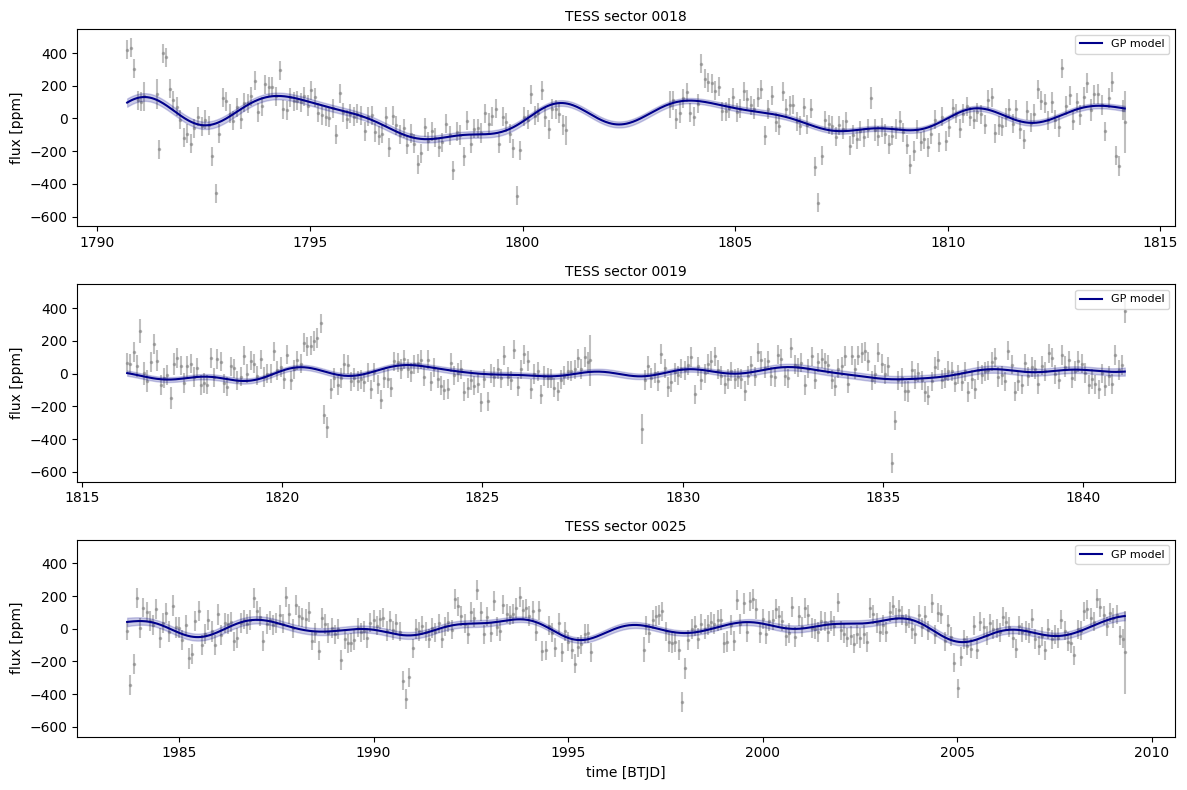

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharey=True)
for ax, (s, bt, bf, be) in zip(axes, sectors[:3]):
    tp = np.linspace(bt.min(), bt.max(), 800)
    mu, var = gp.predict(y, tp, return_var=True)
    sig = np.sqrt(var)
    ax.errorbar(bt - 2457000, (bf-1)*1e6, yerr=be*1e6, fmt=".", ms=3, color="grey", alpha=0.5, zorder=1)
    ax.plot(tp - 2457000, mu*1e6, "-", color="darkblue", lw=1.5, zorder=3, label="GP model")
    ax.fill_between(tp - 2457000, (mu-sig)*1e6, (mu+sig)*1e6, color="darkblue", alpha=0.2, zorder=2)
    ax.set_ylabel("flux [ppm]"); ax.set_title("TESS sector {}".format(s), fontsize=10)
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("time [BTJD]")
plt.tight_layout(); plt.show()

*The fitted rotation period (~10 d) is the photometric activity signal of TOI-1736. For a
full posterior on the rotation parameters, pass `run_mcmc=True` (and optionally
`output_pairsplot=...`) to `star_rotation_gp`, or use the `gp_analysis` command-line tool.*

## 2. Radial velocities and activity indicators

The SOPHIE data provide, for each epoch, the RV plus several **activity indicators**: the
cross-correlation function FWHM and bisector span (BIS), and the chromospheric S-index and
H-alpha index. `rvutils.load_rvdata_from_rdbfiles` reads them all from the `.rdb` file.

In [5]:
rvfile = DATA + "TOI-1736_sophie_drsrvs_ccftool.rdb"
rvdata = rvutils.load_rvdata_from_rdbfiles([rvfile], factor=1.0, verbose=False)   # keep km/s

bjd = rvdata["bjds"][0]; rv = rvdata["rvs"][0]; rverr = rvdata["rverrs"][0]
fwhm = rvdata["fwhms"][0]; bis = rvdata["biss"][0]
sindex = rvdata["sindexs"][0]; ha = rvdata["has"][0]
print("{} SOPHIE RVs over {:.0f} days".format(len(bjd), bjd.max()-bjd.min()))
print("RV rms: {:.1f} m/s".format(np.std(rv)*1000))

152 SOPHIE RVs over 934 days
RV rms: 161.5 m/s


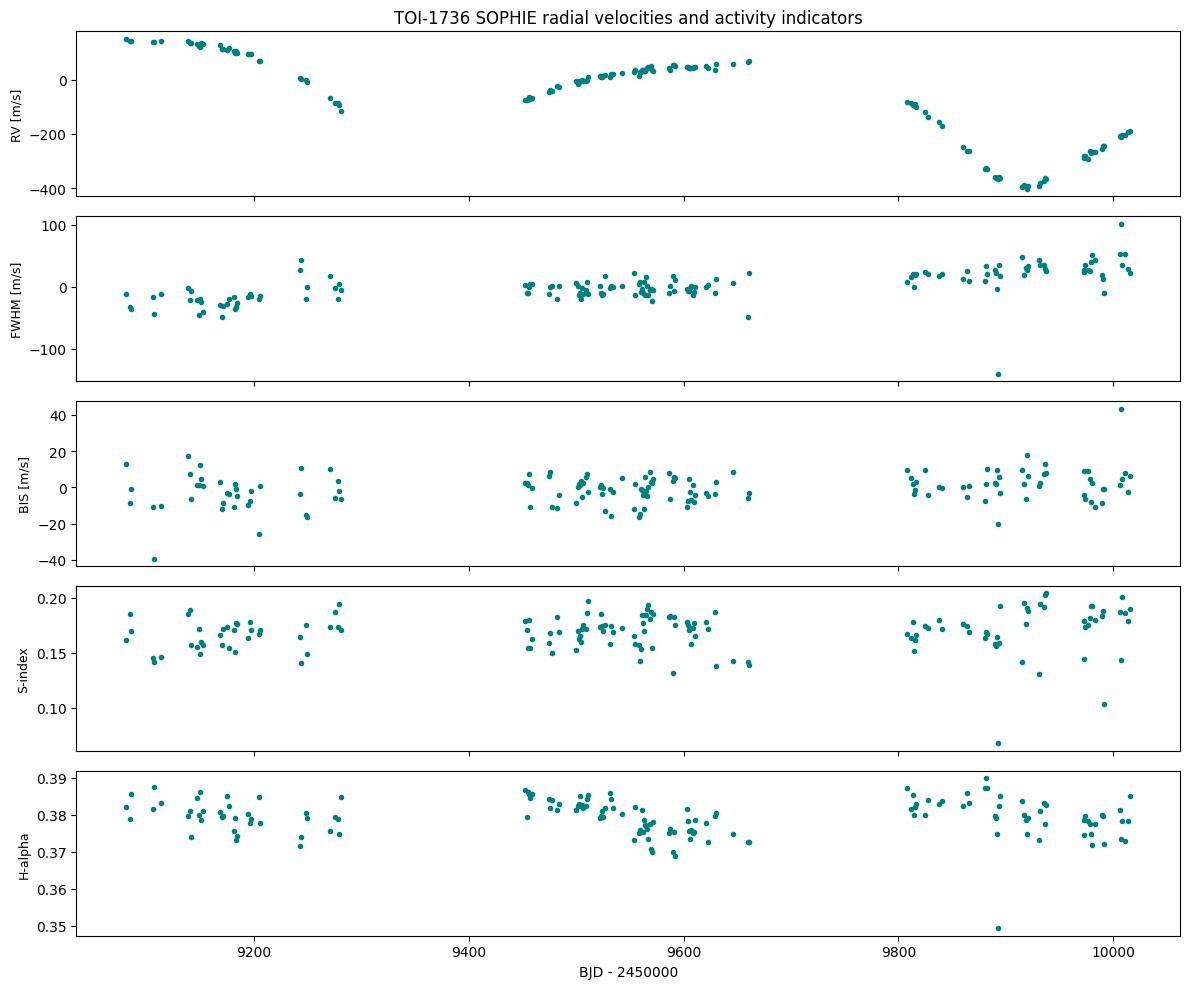

In [6]:
indicators = [("RV [m/s]", (rv-np.median(rv))*1000),
              ("FWHM [m/s]", fwhm-np.median(fwhm)),
              ("BIS [m/s]", bis-np.median(bis)),
              ("S-index", sindex),
              ("H-alpha", ha)]
fig, axes = plt.subplots(len(indicators), 1, figsize=(12, 10), sharex=True)
for ax, (name, val) in zip(axes, indicators):
    ax.plot(bjd - 2450000, val, "o", ms=3, color="teal")
    ax.set_ylabel(name, fontsize=9)
axes[-1].set_xlabel("BJD - 2450000")
axes[0].set_title("TOI-1736 SOPHIE radial velocities and activity indicators")
plt.tight_layout(); plt.show()

## 3. Periodograms

We compute GLS periodograms of the RVs and of each activity indicator. The RV periodogram is
dominated by the long-period, high-amplitude companion TOI-1736 c (~570 d). Comparing the
peaks in the RVs with those in the activity indicators helps separate planetary from activity
signals: a peak that appears in both is suspect.

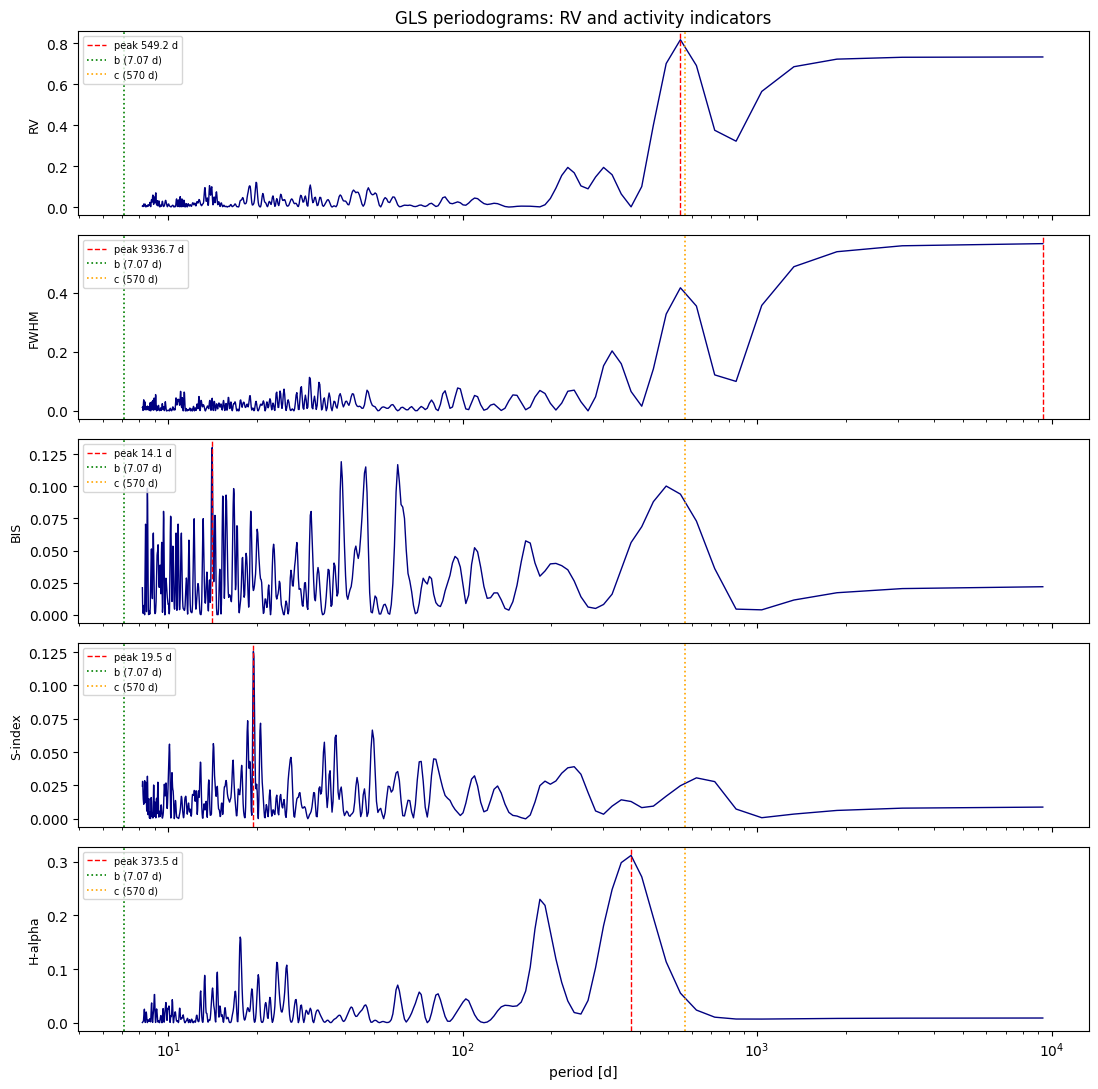

In [7]:
series = [("RV", (rv-np.median(rv))*1000, rverr*1000),
          ("FWHM", fwhm-np.median(fwhm), rvdata["sig_fwhms"][0]),
          ("BIS", bis-np.median(bis), rvdata["sig_biss"][0]),
          ("S-index", sindex, rvdata["sig_sindexs"][0]),
          ("H-alpha", ha, rvdata["sig_has"][0])]

fig, axes = plt.subplots(len(series), 1, figsize=(11, 11), sharex=True)
for ax, (name, val, err) in zip(axes, series):
    gp_pg = timeseries_lib.periodogram(bjd, val, err, nyquist_factor=1.5,
                                       probabilities=[0.01], npeaks=1, y_label=name, plot=False)
    ax.semilogx(1.0/gp_pg["frequency"], gp_pg["power"], "-", color="navy", lw=1)
    ax.axvline(gp_pg["period"], color="red", ls="--", lw=1,
               label="peak {:.1f} d".format(gp_pg["period"]))
    # mark the known planet periods
    for P, c, lbl in [(7.073, "green", "b (7.07 d)"), (570.2, "orange", "c (570 d)")]:
        ax.axvline(P, color=c, ls=":", lw=1.2, label=lbl)
    ax.set_ylabel(name, fontsize=9); ax.legend(fontsize=7, loc="upper left")
axes[-1].set_xlabel("period [d]")
axes[0].set_title("GLS periodograms: RV and activity indicators")
plt.tight_layout(); plt.show()

## 4. RV vs activity correlations

A direct way to check whether the RVs are contaminated by activity is to correlate them with
the activity indicators. But this must be done carefully: strong *planetary* signals can
induce apparent correlations simply through the time sampling. The right diagnostic is to
correlate the **RV residuals** (after removing the planetary orbits) with the indicators.

First, the raw RVs vs the indicators:

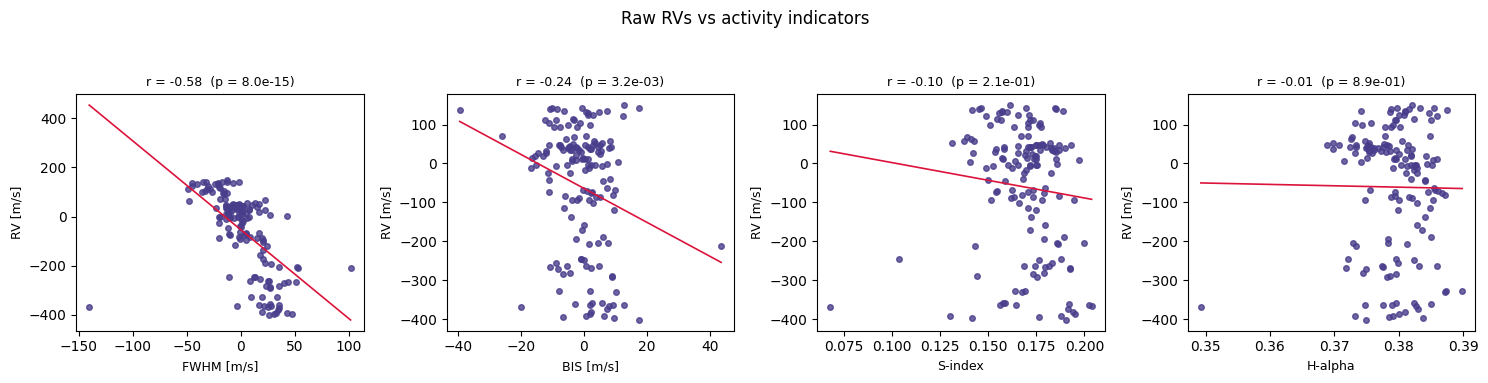

In [8]:
from scipy.stats import pearsonr

def corr_panel(ax, x, y, xlabel, ylabel):
    ax.plot(x, y, "o", ms=4, color="darkslateblue", alpha=0.8)
    r, p = pearsonr(x, y)
    # linear trend line
    b1, b0 = np.polyfit(x, y, 1)
    xs = np.array([x.min(), x.max()])
    ax.plot(xs, b0 + b1*xs, "-", color="crimson", lw=1.2)
    ax.set_xlabel(xlabel, fontsize=9); ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title("r = {:+.2f}  (p = {:.1e})".format(r, p), fontsize=9)
    return r, p

rv_ms = (rv - np.median(rv))*1000
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
corr_panel(axes[0], fwhm-np.median(fwhm), rv_ms, "FWHM [m/s]", "RV [m/s]")
corr_panel(axes[1], bis-np.median(bis), rv_ms, "BIS [m/s]", "RV [m/s]")
corr_panel(axes[2], sindex, rv_ms, "S-index", "RV [m/s]")
corr_panel(axes[3], ha, rv_ms, "H-alpha", "RV [m/s]")
fig.suptitle("Raw RVs vs activity indicators", y=1.05)
plt.tight_layout(); plt.show()

### RV residuals vs activity

Now we fit the two-planet orbital model (as in the paper's RV analysis) and correlate the
**residuals** with the indicators. If the raw correlation was driven by the planets' sampling
rather than by activity, it will weaken substantially in the residuals.

In [9]:
import shutil
priors_file = "outputs/TOI-1736_rv.pars"
shutil.copyfile(DATA + "TOI-1736.pars", priors_file)

priors = fitlib.read_rv_priors(priors_file, 1, verbose=False)
post = fitlib.guess_rvcalib(priors, [bjd], [rv], prior_type="Normal", plot=False)
post = fitlib.fit_RVs_ols([bjd], [rv], [rverr], post, fix_eccentricity=False,
                          rvcalib_post_type="Normal", calib_unc=0.01, verbose=False, plot=False)

pp = post["planet_params"]; rc = post["rvcalib_params"]
rv_model = fitlib.calculate_rv_model_new(bjd, pp, include_trend=True) + rc["rv_d00"]
resid = (rv - rv_model) * 1000   # m/s
print("RV rms: {:.1f} m/s  ->  residual rms after removing planets b & c: {:.1f} m/s".format(
    np.std(rv)*1000, np.std(resid)))

median_rv (no prior model considered) =  -25.40895
median_rv= -25.841900063578326
Free parameters before OLS fit:
k_000 = 4.059793295514452
tc_000 = 2458792.794738671
per_000 = 7.073087509539559
a_000 = 13.373319021106258
rp_000 = 0.020579837441617437
inc_000 = 89.44408078972697
u0_000 = 0.014133345981293122
u1_000 = 0.227236374993042
k_001 = 201.10004272409657
tc_001 = 2455282.956124695
per_001 = 570.1167348993636
trend_001 = -0.17741423705301984
rv_d00 = -25.841900063578326
Free parameters after OLS fit:
k_000 = 4.059793295514452
tc_000 = 2458792.794738671
per_000 = 7.073087509539559
a_000 = 13.373319021106258
rp_000 = 0.020579837441617437
inc_000 = 89.44408078972697
u0_000 = 0.014133345981293122
u1_000 = 0.227236374993042
k_001 = 201.10004272409657
tc_001 = 2455282.956124695
per_001 = 570.1167348993636
trend_001 = -0.17741423705301984
rv_d00 = -435714.5344237349
RV rms: 161.5 m/s  ->  residual rms after removing planets b & c: 41.5 m/s


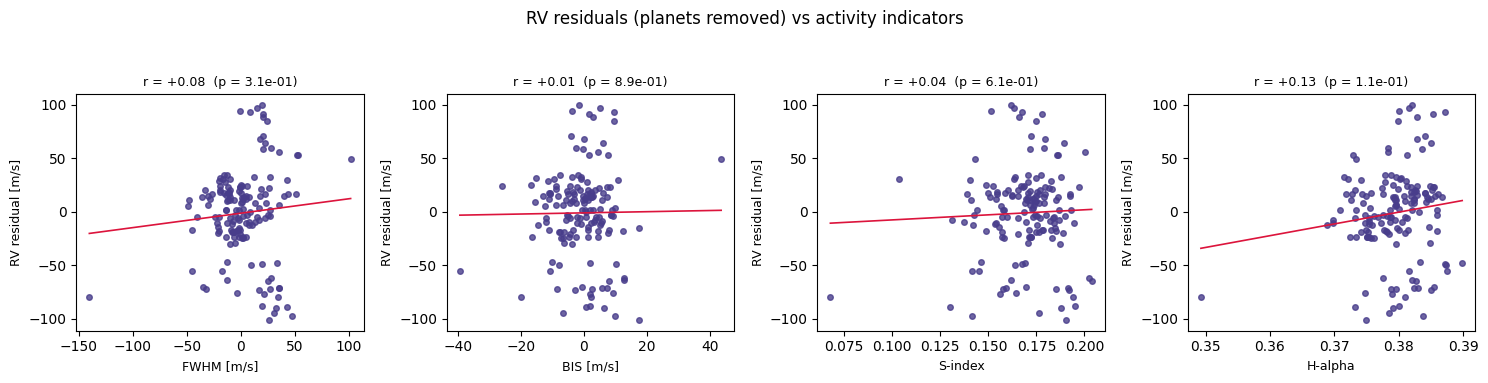

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
corr_panel(axes[0], fwhm-np.median(fwhm), resid, "FWHM [m/s]", "RV residual [m/s]")
corr_panel(axes[1], bis-np.median(bis), resid, "BIS [m/s]", "RV residual [m/s]")
corr_panel(axes[2], sindex, resid, "S-index", "RV residual [m/s]")
corr_panel(axes[3], ha, resid, "H-alpha", "RV residual [m/s]")
fig.suptitle("RV residuals (planets removed) vs activity indicators", y=1.05)
plt.tight_layout(); plt.show()

Comparing the two figures shows how much of the apparent RV-activity correlation was in fact
induced by the planetary signals: once the orbits of TOI-1736 b and c are removed, the
residual RVs show little correlation with the activity indicators, indicating the RVs are not
strongly contaminated by activity — consistent with the analysis in Martioli et al. (2023).

## 5. Command-line equivalents

Everything shown here is also available from the command line. The published step-by-step
analysis of TOI-1736 used, for example:

```bash
# RV-only fit with activity-index detrending and jitter, plus plots
rv_fit_detrend --rvdata=TOI-1736_sophie_drsrvs+ccftool.rdb \
               --planet_priors=TOI-1736_rv_only.pars -vjpm

# stand-alone GP analysis of a time series (photometry or an activity index)
gp_analysis --input=<timeseries.rdb> --run_gp_mcmc -rvp

# transit-only and joint transit+RV fits
transit_fit --object="TOI-1736" --lcdata="TESS/*lc.fits" \
            --planet_priors=TOI-1736_transits_only.pars --walkers=50 --nsteps=3000 --burnin=1000 -vpl
transit_rv_fit --object="TOI-1736" --lcdata="TESS/*lc.fits" \
               --rvdata=TOI-1736_sophie_drsrvs+ccftool.rdb \
               --planet_priors=TOI-1736.pars --nsteps=1000 --walkers=50 --burnin=300 -vpjmf
```

### Summary

- `gp_lib.star_rotation_gp` fits a quasi-periodic (rotation) GP to a time series and returns a
  `george` GP object you can predict with; `gp_analysis` is the command-line front end.
- Activity indicators are read alongside the RVs by `rvutils.load_rvdata_from_rdbfiles`.
- Periodograms (`timeseries_lib.periodogram`) and RV-vs-indicator correlations — especially of
  the RV *residuals* — are the key diagnostics for distinguishing planetary from activity
  signals. For TOI-1736 the residual correlations are weak, supporting the planetary
  interpretation of the RV signals.